In [2]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

print("DataFrame Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

df_numeric = df.select_dtypes(include=["number"])

print("\nDataFrame Info after preprocessing:")
df_numeric.info()
print("\nMissing Values after preprocessing:")
print(df_numeric.isnull().sum())

df_numeric.to_csv("titanic_preprocessed.csv", index=False)
print("\nPreprocessed data saved to titanic_preprocessed.csv")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Em

C:\Users\muckz\AppData\Local\Temp\ipykernel_32012\2309893195.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\muckz\AppData\Local\Temp\ipykernel_32012\2309893195.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_preprocessed.csv")

# Gráfico de dispersão 1: Idade vs. Tarifa
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Age", y="Fare", data=df, alpha=0.6)
plt.title("Idade vs. Tarifa no Titanic")
plt.xlabel("Idade")
plt.ylabel("Tarifa")
plt.grid(True)
plt.tight_layout()
plt.savefig("idade_vs_tarifa_dispersao.png")
plt.close()

# Gráfico de dispersão 2: Idade vs. Classe de Passageiro
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Age", y="Pclass", data=df, alpha=0.6)
plt.title("Idade vs. Classe de Passageiro no Titanic")
plt.xlabel("Idade")
plt.ylabel("Classe de Passageiro")
plt.grid(True)
plt.tight_layout()
plt.savefig("idade_vs_classe_dispersao.png")
plt.close()

# Gráfico de dispersão 3: Tarifa vs. Classe de Passageiro
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Fare", y="Pclass", data=df, alpha=0.6)
plt.title("Tarifa vs. Classe de Passageiro no Titanic")
plt.xlabel("Tarifa")
plt.ylabel("Classe de Passageiro")
plt.grid(True)
plt.tight_layout()
plt.savefig("tarifa_vs_classe_dispersao.png")
plt.close()

print("Gráficos de dispersão gerados e salvos como idade_vs_tarifa_dispersao.png, idade_vs_classe_dispersao.png e tarifa_vs_classe_dispersao.png.")

Gráficos de dispersão gerados e salvos como idade_vs_tarifa_dispersao.png, idade_vs_classe_dispersao.png e tarifa_vs_classe_dispersao.png.


C:\Users\muckz\AppData\Local\Temp\ipykernel_32012\728543939.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)


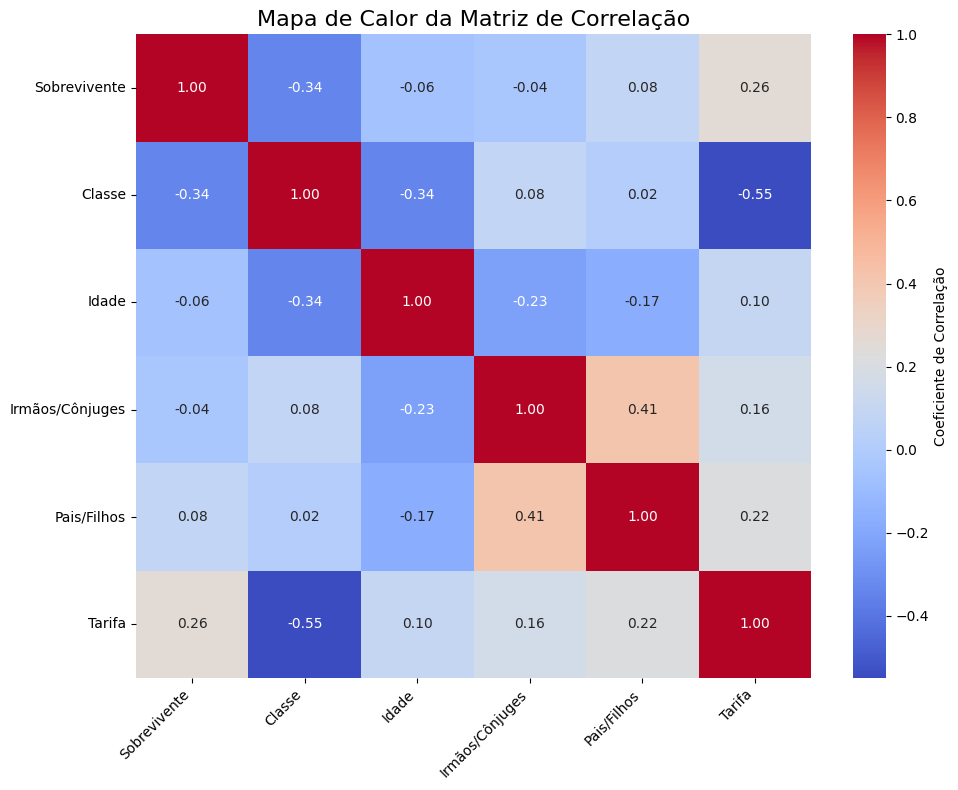

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_titanic = pd.read_csv('Titanic-Dataset.csv')

df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)

column_mapping = {
    'Survived': 'Sobrevivente',
    'Pclass': 'Classe',
    'Age': 'Idade',
    'SibSp': 'Irmãos/Cônjuges',
    'Parch': 'Pais/Filhos',
    'Fare': 'Tarifa'
}

df_titanic.rename(columns=column_mapping, inplace=True)

numerical_cols_pt = list(column_mapping.values())
correlation_matrix_pt = df_titanic[numerical_cols_pt].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_pt, annot=True, cmap='coolwarm', fmt=".2f",
            cbar_kws={'label': 'Coeficiente de Correlação'})
plt.title('Mapa de Calor da Matriz de Correlação', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()